In [9]:
#Imports 
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import sklearn
from sklearn.linear_model import Perceptron
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [10]:
Combine_Data = pd.read_csv("2021Combine.csv")
Combine_Data.head()

,Name,Pos,School,Height,Weight,Hands,Arms,Wingspan,40 Yd,10 Split,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,NaN,NaN,NaN,4.60,NaN,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,NaN,NaN,NaN,4.61,NaN,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,NaN,NaN,NaN,4.52,NaN,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,NaN,NaN,NaN,4.51,NaN,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,NaN,NaN,NaN,4.27,NaN,32.0,"10'3""",NaN,7.13,4.25


In [11]:
Combine_df = pd.DataFrame(Combine_Data)
Combine_df = Combine_df.drop(['Hands', 'Arms', 'Wingspan', '10 Split'], axis = 1) #Dropping NaN columns
Combine_df.head()

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,4.60,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,4.61,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",NaN,7.13,4.25


In [12]:
WR_df = Combine_df.loc[Combine_df['Pos'] == 'WR'] #filtering to only get the WR position
WR_df.head()

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,4.60,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,4.61,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",NaN,7.13,4.25


In [13]:
WR_df = WR_df.fillna(0)
pd.set_option('display.max_rows', None) #Displaying the entire new dataset to ensure accuarcy
pd.set_option('display.max_columns', None)

print(WR_df)

                         Name Pos           School Height  Weight  40 Yd  \
0               Adam Krumholz  WR        Wisconsin   6'0"   193.0   4.60   
1                Adrian Hardy  WR   Louisiana Tech   6'1"   205.0   4.61   
2               Amari Rodgers  WR          Clemson   5'9"   212.0   4.52   
3           Amon-Ra St. Brown  WR              USC  5'11"   197.0   4.51   
4            Anthony Schwartz  WR           Auburn   6'0"   186.0   4.27   
5                Antonio Nunn  WR          Buffalo  5'11"   204.0   4.50   
8              Bailey Gaither  WR     San Jose St.   6'0"   188.0   4.45   
10              Ben Skowronek  WR       Notre Dame   6'2"   220.0   0.00   
11               Blake Proehl  WR    East Carolina   6'1"   186.0   4.47   
14               Branden Mack  WR           Temple   6'5"   217.0   4.66   
15              Brandon Smith  WR             Iowa   6'1"   218.0   4.62   
17             Brennan Eagles  WR            Texas   6'3"   225.0   4.55   
27          

In [14]:
pff_values = [
    # 1–15
    0.00, 0.00, 58.00, 91.00, 56.00,
    0.00, 0.00, 62.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 57.00, 60.00,

    # 16–30
    0.00, 0.00, 64.00, 60.00, 0.00,
    59.00, 0.00, 62.00, 0.00, 72.00,
    58.00, 61.00, 0.00, 90.00, 60.00,

    # 31–45
    64.00, 58.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 66.00, 0.00,
    0.00, 0.00, 60.00, 78.00, 60.00,

    # 46–end
    0.00, 74.00, 0.00, 78.00, 0.00,
    0.00, 55.00, 0.00, 0.00, 67.00,
    0.00, 0.00, 0.00, 68.00, 62.00,
    0.00, 0.00, 0.00
]

WR_df["PFF"] = pff_values #Manually implementing the PFF values for each player

print(WR_df[["PFF"]].head())
print(len(WR_df), len(pff_values))

    PFF
0   0.0
1   0.0
2  58.0
3  91.0
4  56.0
63 63


In [15]:
pd.set_option('display.max_rows', None) #Checking full dataset once again
pd.set_option('display.max_columns', None)

print(WR_df)

                         Name Pos           School Height  Weight  40 Yd  \
0               Adam Krumholz  WR        Wisconsin   6'0"   193.0   4.60   
1                Adrian Hardy  WR   Louisiana Tech   6'1"   205.0   4.61   
2               Amari Rodgers  WR          Clemson   5'9"   212.0   4.52   
3           Amon-Ra St. Brown  WR              USC  5'11"   197.0   4.51   
4            Anthony Schwartz  WR           Auburn   6'0"   186.0   4.27   
5                Antonio Nunn  WR          Buffalo  5'11"   204.0   4.50   
8              Bailey Gaither  WR     San Jose St.   6'0"   188.0   4.45   
10              Ben Skowronek  WR       Notre Dame   6'2"   220.0   0.00   
11               Blake Proehl  WR    East Carolina   6'1"   186.0   4.47   
14               Branden Mack  WR           Temple   6'5"   217.0   4.66   
15              Brandon Smith  WR             Iowa   6'1"   218.0   4.62   
17             Brennan Eagles  WR            Texas   6'3"   225.0   4.55   
27          

In [16]:
PFF_labels = WR_df["PFF"] #Creating Labels

features = WR_df.drop(['Name', 'Pos', 'School', 'Height','PFF', 'Broad'], axis=1) #Creating Features

#Seperating into training and testing values
train_vectors, test_vectors, train_labels, test_labels = train_test_split(features, PFF_labels, test_size=0.25, random_state=42) 

#Setting up and fitting the linear regression model
model = LinearRegression() 
model.fit(train_vectors, train_labels)

preds = model.predict(test_vectors) #predicting with the test vector

X = sm.add_constant(train_vectors) #Creating constant 
model = sm.OLS(train_labels, X).fit() #Fitting the new model with the constant 

print(model.summary()) #Showing summary

                            OLS Regression Results                            
Dep. Variable:                    PFF   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.9123
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.496
Time:                        23:13:33   Log-Likelihood:                -228.46
No. Observations:                  47   AIC:                             470.9
Df Residuals:                      40   BIC:                             483.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8425     20.610      1.448      0.1

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

print(r2_score(test_labels, preds))
print(mean_absolute_error(test_labels,preds))

-0.8023571687058544
31.13349412706993


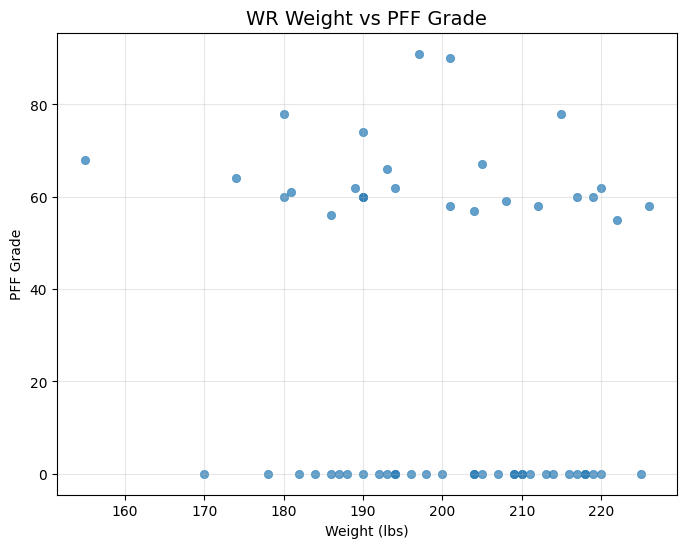

In [18]:
WR_df = WR_df.dropna(subset=["Weight", "PFF"])
WR_df = WR_df[(WR_df["Weight"] > 140) & (WR_df["Weight"] < 280)]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=WR_df,
    x="Weight",
    y="PFF",
    alpha=0.7,
    edgecolor=None
)

plt.title("WR Weight vs PFF Grade", fontsize=14)
plt.xlabel("Weight (lbs)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)

plt.show()

In [19]:
good_WR_df = WR_df[WR_df["PFF"] > 40]
good_WR_df

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle,PFF
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31,58.0
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17,91.0
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",0.0,7.13,4.25,56.0
10,Ben Skowronek,WR,Notre Dame,"6'2""",220.0,0.00,0.0,0,13.0,0.00,0.00,62.0
29,Cornell Powell,WR,Clemson,"6'0""",204.0,4.53,36.5,"10'8""",16.0,7.03,4.21,57.0
30,D'Wayne Eskridge,WR,West. Michigan,"5'8""",190.0,4.38,35.0,"10'4""",0.0,6.93,4.22,60.0
37,Dazz Newsome,WR,North Carolina,"5'10""",190.0,4.59,34.0,"10'1""",12.0,7.38,4.38,60.0
42,Dez Fitzpatrick,WR,Louisville,"6'1""",208.0,4.43,35.0,0,0.0,7.09,4.26,59.0
44,Dyami Brown,WR,North Carolina,"6'0""",189.0,4.46,35.0,"10'8""",18.0,6.87,4.35,62.0
49,Frank Darby,WR,Arizona St.,"6'0""",201.0,4.56,34.5,"9'9""",19.0,7.05,4.25,58.0


In [20]:
PFF_labels_good = good_WR_df["PFF"]

features_good = good_WR_df.drop(['Name', 'Pos', 'School', 'Height','PFF',  'Broad'], axis=1)

train_vectors_good, test_vectors_good, train_labels_good, test_labels_good = train_test_split(features_good, PFF_labels_good, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(train_vectors_good, train_labels_good)

preds = model.predict(test_vectors_good)

X = sm.add_constant(train_vectors_good)
model = sm.OLS(train_labels_good, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PFF   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.9223
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.515
Time:                        23:13:42   Log-Likelihood:                -62.043
No. Observations:                  18   AIC:                             138.1
Df Residuals:                      11   BIC:                             144.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        118.9052     47.166      2.521      0.0

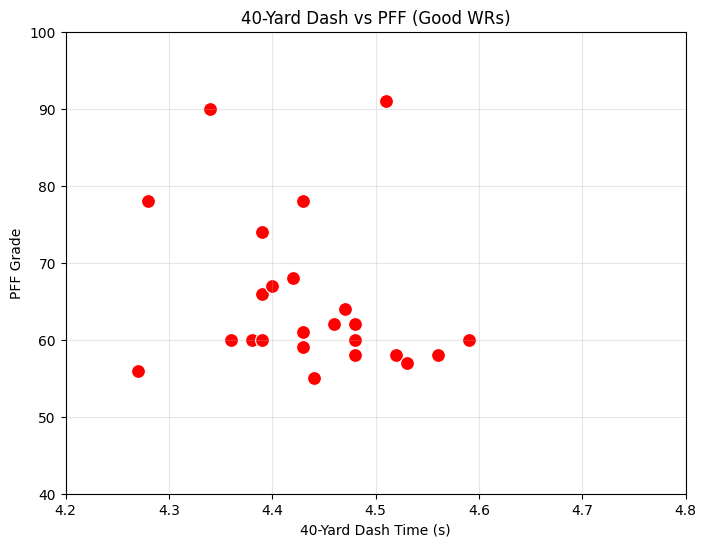

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=good_WR_df,
    x="40 Yd",
    y="PFF",
    s = 100,
    color = 'red'
)
plt.xlim(4.2, 4.8)
plt.ylim(40, 100)
plt.title("40-Yard Dash vs PFF (Good WRs)")
plt.xlabel("40-Yard Dash Time (s)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)
plt.show()

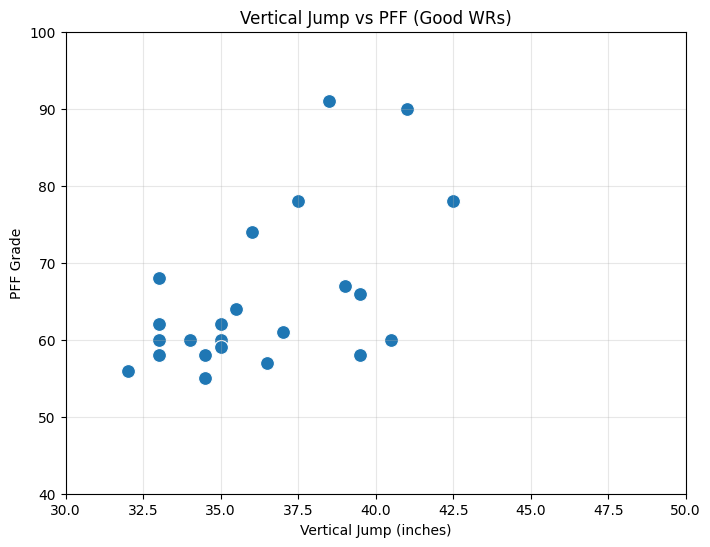

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=good_WR_df,
    x="Vertical",
    y="PFF",
    s = 100
)

plt.xlim(30, 50)
plt.ylim(40, 100)
plt.title("Vertical Jump vs PFF (Good WRs)")
plt.xlabel("Vertical Jump (inches)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)
plt.show()

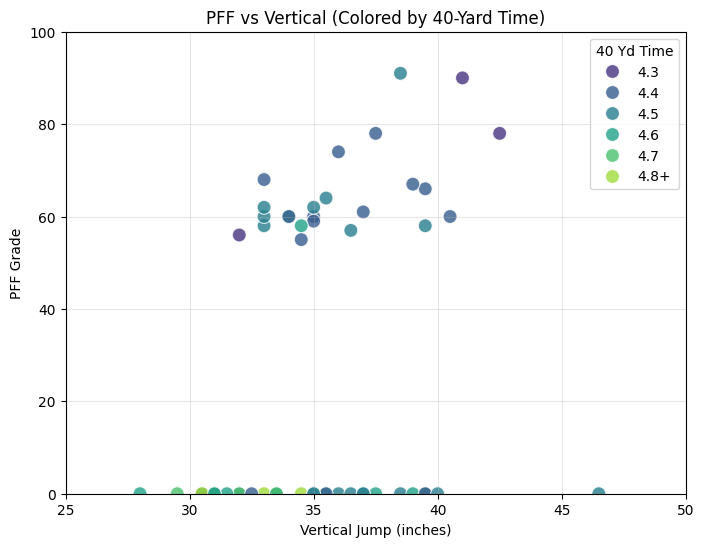

In [23]:
bins = [4.2, 4.35, 4.45, 4.55, 4.65, 4.75, 5.0]
labels = ["4.3", "4.4", "4.5", "4.6", "4.7", "4.8+"]
WR_df["40_bin"] = pd.cut(WR_df["40 Yd"], bins=bins, labels=labels)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=WR_df,
    x="Vertical",
    y="PFF",
    hue="40_bin",          
    palette="viridis",    
    s=100,
    alpha=0.8
)
plt.xlim(25, 50)
plt.ylim(0, 100)

plt.title("PFF vs Vertical (Colored by 40-Yard Time)")
plt.xlabel("Vertical Jump (inches)")
plt.ylabel("PFF Grade")

plt.legend(title="40 Yd Time")
plt.grid(True, alpha=0.3)

plt.show()



/tmp/ipykernel_2993904/651629907.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_WR_df["40_bin2"] = pd.cut(good_WR_df["40 Yd"], bins=bins2, labels=labels2)


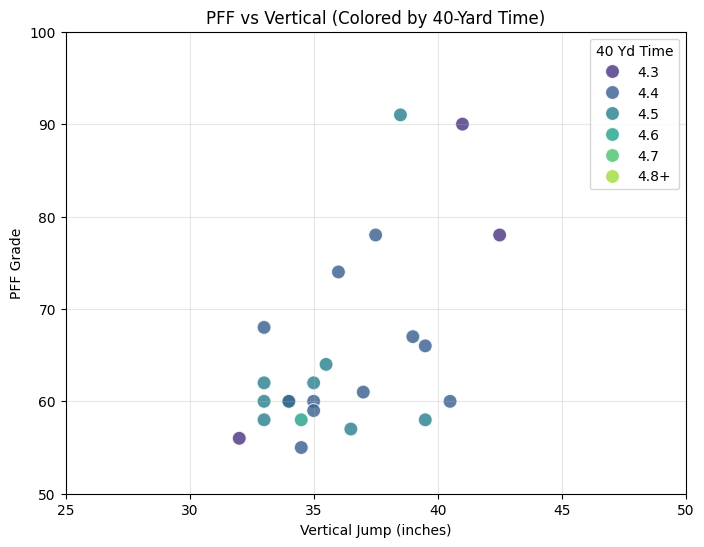

In [24]:
bins2 = [4.2, 4.35, 4.45, 4.55, 4.65, 4.75, 5.0]
labels2 = ["4.3", "4.4", "4.5", "4.6", "4.7", "4.8+"]
good_WR_df["40_bin2"] = pd.cut(good_WR_df["40 Yd"], bins=bins2, labels=labels2)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=good_WR_df,
    x="Vertical",
    y="PFF",
    hue="40_bin2",          
    palette="viridis",    
    s=100,
    alpha=0.8
)
plt.xlim(25, 50)
plt.ylim(50, 100)

plt.title("PFF vs Vertical (Colored by 40-Yard Time)")
plt.xlabel("Vertical Jump (inches)")
plt.ylabel("PFF Grade")

plt.legend(title="40 Yd Time")
plt.grid(True, alpha=0.3)

plt.show()

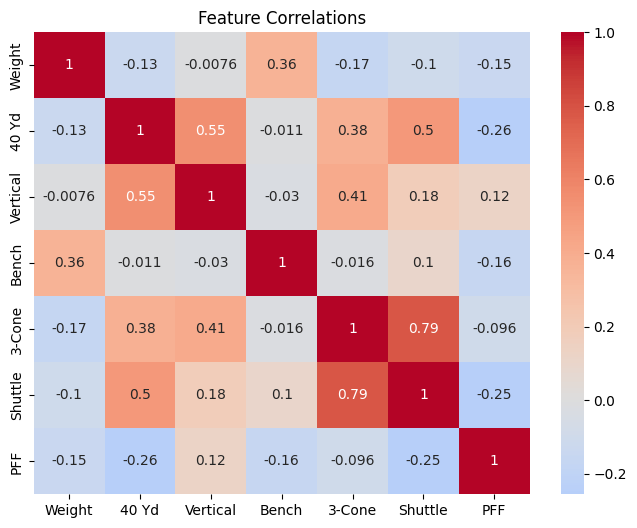

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    WR_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations")

plt.show()

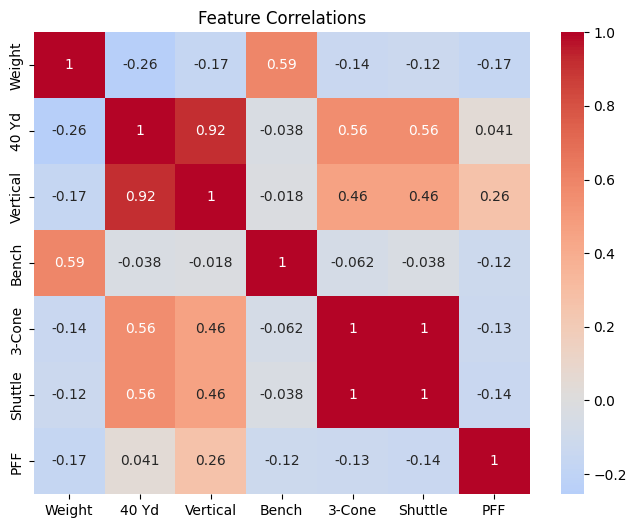

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    good_WR_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations")

plt.show()